In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:
def elasticity_matrix(youngs_modulus: float, poissons_ratio: float, stress_state: str) -> np.ndarray:
    """Compute the elasticity (stiffness) matrix for an isotropic elastic material.
    
    Args:
        youngs_modulus: Young's modulus of the material.
        poissons_ratio: Poisson's ratio of the material.
        stress_state: Type of stress state. Must be one of "PLANE_STRESS", 
                      "PLANE_STRAIN", or "3D".
    
    Returns:
        Elasticity matrix as a numpy array.
        
    Raises:
        ValueError: If an invalid stress_state is provided.
    """
    if stress_state == 'PLANE_STRESS':
        C = youngs_modulus / (1 - poissons_ratio**2) * np.array([
            [1, poissons_ratio, 0],
            [poissons_ratio, 1, 0],
            [0, 0, (1 - poissons_ratio) / 2]
        ])
    elif stress_state == 'PLANE_STRAIN':
        C = youngs_modulus / ((1 + poissons_ratio) * (1 - 2 * poissons_ratio)) * np.array([
            [1 - poissons_ratio, poissons_ratio, 0],
            [poissons_ratio, 1 - poissons_ratio, 0],
            [0, 0, 0.5 - poissons_ratio]
        ])
    else:  # 3D stress state
        C = np.zeros((6, 6))
        C[:3, :3] = youngs_modulus / ((1 + poissons_ratio) * (1 - 2 * poissons_ratio)) * np.array([
            [1 - poissons_ratio, poissons_ratio, poissons_ratio],
            [poissons_ratio, 1 - poissons_ratio, poissons_ratio],
            [poissons_ratio, poissons_ratio, 1 - poissons_ratio]
        ])
        C[3:, 3:] = youngs_modulus / (2 * (1 + poissons_ratio)) * np.eye(3)
    return C

In [4]:
def generate_circle_particles(center: list, radius: float, spacing: float) -> np.ndarray:
    """Generate a set of particle coordinates within a circle.
    
    Args:
        center: [x, y] coordinates of the circle center.
        radius: Radius of the circle.
        spacing: Grid spacing between particles.
    
    Returns:
        Array of particle positions, each row as [x, y].
    """
    center_array = np.array(center)
    # Determine grid origin so that the grid is consistent regardless of the circle center.
    grid_origin = (center_array // spacing) * spacing

    # Define grid limits based on the circle radius.
    xmin, ymin = grid_origin - radius
    xmax, ymax = grid_origin + radius

    # Generate grid points.
    x_coords = np.arange(xmin, xmax + spacing, spacing)
    y_coords = np.arange(ymin, ymax + spacing, spacing)
    Xp, Yp = np.meshgrid(x_coords, y_coords)
    Xp = Xp.flatten()
    Yp = Yp.flatten()

    # Keep only points that lie inside the circle.
    inside = (Xp - center_array[0])**2 + (Yp - center_array[1])**2 <= radius**2
    return np.vstack([Xp[inside], Yp[inside]]).T

In [5]:
def particle_element_mapping(particle_positions: np.ndarray, cell_width: float, cell_height: float,
                             n_ele_x: int, n_elements: int):
    """Map each particle to an element based on its position.
    
    Args:
        particle_positions: Particle positions as an array of shape (n_particles, 2).
        cell_width: Element (cell) width in the x-direction.
        cell_height: Element (cell) height in the y-direction.
        n_ele_x: Number of elements in the x-direction.
        n_elements: Total number of elements.
    
    Returns:
        ele_ids: Array of element ids for each particle.
        particle_ids_in_elements: List of particle indices for each element.
    """
    x_indices = np.floor(particle_positions[:, 0] / cell_width).astype(int)
    y_indices = np.floor(particle_positions[:, 1] / cell_height).astype(int)
    ele_ids = x_indices + n_ele_x * y_indices

    particle_ids_in_elements = [[] for _ in range(n_elements)]
    for p, e in enumerate(ele_ids):
        particle_ids_in_elements[e].append(p)

    return ele_ids, particle_ids_in_elements

In [6]:
def lagrange_basis(element_type: str, local_coord: np.ndarray):
    """Compute the shape functions and their derivatives for a finite element.
    
    Args:
        element_type: Type of element. Currently only "Q4" is supported.
        local_coord: Array of local coordinates [xi, eta].
    
    Returns:
        N: Shape function values.
        dN_dxi: Derivatives of the shape functions with respect to xi and eta.
        
    Raises:
        ValueError: If an unsupported element type is provided.
    """
    if element_type == 'Q4':
        xi, eta = local_coord
        N = np.array([
            (1 - xi) * (1 - eta),
            (1 + xi) * (1 - eta),
            (1 + xi) * (1 + eta),
            (1 - xi) * (1 + eta)
        ]) / 4.0

        dN_dxi = np.array([
            [-(1 - eta), -(1 - xi)],
            [ (1 - eta), -(1 + xi)],
            [ (1 + eta),  (1 + xi)],
            [-(1 + eta),  (1 - xi)]
        ]) / 4.0
    else:
        raise ValueError(f"Unsupported element type: {element_type}")

    return N, dN_dxi

In [7]:
def compute_local_coord(particle_pos: np.ndarray, element_coords: np.ndarray,
                        cell_width: float, cell_height: float) -> np.ndarray:
    """Compute the local (ξ, η) coordinates for a particle within an element.
    
    Args:
        particle_pos: [x, y] coordinates of the particle.
        element_coords: Coordinates of the element nodes (4 x 2 array).
        cell_width: Element width in the x-direction.
        cell_height: Element height in the y-direction.
    
    Returns:
        Local coordinates [ξ, η].
    """
    xi = (2 * particle_pos[0] - (element_coords[0, 0] + element_coords[1, 0])) / cell_width
    eta = (2 * particle_pos[1] - (element_coords[1, 1] + element_coords[2, 1])) / cell_height
    return np.array([xi, eta])

In [8]:
def particle_to_node(particles: dict, nodes: np.ndarray, elements: np.ndarray,
                     particle_ids_in_elements: list, cell_width: float, cell_height: float,
                     time_step: float, gravity: float, boundaries: dict) -> dict:
    """Transfer physical quantities from particles to grid nodes.
    
    Args:
        particles: Dictionary containing particle data with keys:
            "positions": Particle positions.
            "velocities": Particle velocities.
            "stresses": Particle stresses.
            "masses": Particle masses.
            "volumes": Particle volumes.
        nodes: Array of nodal coordinates.
        elements: Element connectivity; each row has node indices for an element.
        particle_ids_in_elements: List of particle indices for each element.
        cell_width: Element width in the x-direction.
        cell_height: Element height in the y-direction.
        time_step: Time increment.
        gravity: Gravity acceleration (acting downward).
        boundaries: Dictionary specifying Dirichlet boundary nodes with keys:
            "left", "right", "bottom", and "top".
    
    Returns:
        Dictionary containing nodal data with keys:
            "coordinates": Nodal coordinates.
            "masses": Nodal masses.
            "momenta": Nodal momenta.
            "net_force": Net forces at nodes.
            "stresses": Nodal stresses.
    """
    positions = particles["positions"]
    velocities = particles["velocities"]
    stresses = particles["stresses"]
    masses = particles["masses"]
    volumes = particles["volumes"]

    n_nodes = len(nodes)
    nodal_masses = np.zeros(n_nodes)
    nodal_momenta = np.zeros((n_nodes, 2))
    nodal_internal_forces = np.zeros((n_nodes, 2))
    nodal_external_forces = np.zeros((n_nodes, 2))
    nodal_stresses = np.zeros((n_nodes, 3))

    n_elements = elements.shape[0]
    active_elements = [ele for ele in range(n_elements) if len(particle_ids_in_elements[ele]) > 0]

    for ele in active_elements:
        node_ids = elements[ele]
        element_coords = nodes[node_ids, :]  # (4 x 2) coordinates for current element nodes
        for p in particle_ids_in_elements[ele]:
            local_coord = compute_local_coord(positions[p], element_coords, cell_width, cell_height)
            shape, dN_dxi = lagrange_basis("Q4", local_coord)
            jacobian = element_coords.T @ dN_dxi
            inv_jacobian = np.linalg.inv(jacobian)
            dN_dx = dN_dxi @ inv_jacobian

            stress = stresses[p]
            for i, node in enumerate(node_ids):
                nodal_masses[node] += shape[i] * masses[p]
                nodal_momenta[node, :] += shape[i] * masses[p] * velocities[p, :]
                nodal_internal_forces[node, 0] -= volumes[p] * (stress[0] * dN_dx[i, 0] + stress[2] * dN_dx[i, 1])
                nodal_internal_forces[node, 1] -= volumes[p] * (stress[2] * dN_dx[i, 0] + stress[1] * dN_dx[i, 1])
                nodal_external_forces[node, 1] -= shape[i] * masses[p] * gravity

    net_nodal_force = nodal_internal_forces + nodal_external_forces

    # Apply Dirichlet boundary conditions.
    left_nodes = boundaries["left"]
    right_nodes = boundaries["right"]
    bottom_nodes = boundaries["bottom"]
    top_nodes = boundaries["top"]

    nodal_momenta[left_nodes, 0] = 0
    nodal_momenta[right_nodes, 0] = 0
    nodal_momenta[bottom_nodes, 1] = 0
    nodal_momenta[top_nodes, 1] = 0

    net_nodal_force[left_nodes, 0] = 0
    net_nodal_force[right_nodes, 0] = 0
    net_nodal_force[bottom_nodes, 1] = 0
    net_nodal_force[top_nodes, 1] = 0

    nodal_momenta += net_nodal_force * time_step

    node_data = {
        "coordinates": nodes,
        "masses": nodal_masses,
        "momenta": nodal_momenta,
        "net_force": net_nodal_force,
        "stresses": nodal_stresses
    }
    return node_data


In [9]:
def node_to_particle(particles: dict, node_data: dict, elements: np.ndarray,
                     particle_ids_in_elements: list, cell_width: float, cell_height: float,
                     time_step: float, elasticity_matrix_C: np.ndarray) -> tuple:
    """Update particle kinematics and stress response using nodal information.
    
    Args:
        particles: Dictionary containing particle data with keys:
            "positions": Particle positions.
            "velocities": Particle velocities.
            "F": Deformation gradients.
            "volumes": Current volumes.
            "stresses": Particle stresses.
            "strains": Particle strains.
            "initial_volumes": Initial volumes.
            "masses": Particle masses.
        node_data: Dictionary containing nodal data with keys:
            "masses": Nodal masses.
            "momenta": Nodal momenta.
            "net_force": Net forces at nodes.
        elements: Element connectivity.
        particle_ids_in_elements: List of particle indices for each element.
        cell_width: Element width in the x-direction.
        cell_height: Element height in the y-direction.
        time_step: Time increment.
        elasticity_matrix_C: Elasticity matrix.
    
    Returns:
        tuple containing:
            - Updated particle dictionary
            - Total kinetic energy
            - Total strain energy
    """
    positions = particles["positions"]
    velocities = particles["velocities"]
    F_all = particles["F"]
    volumes = particles["volumes"]
    stresses = particles["stresses"]
    strains = particles["strains"]
    initial_volumes = particles["initial_volumes"]
    masses_particle = particles["masses"]

    nodal_masses = node_data["masses"]
    nodal_momenta = node_data["momenta"]
    net_nodal_force = node_data["net_force"]

    kinetic_energy = 0.0
    strain_energy = 0.0

    n_elements = elements.shape[0]
    active_elements = [ele for ele in range(n_elements) if len(particle_ids_in_elements[ele]) > 0]

    for ele in active_elements:
        node_ids = elements[ele]
        element_coords = node_data["coordinates"][node_ids, :]
        for p in particle_ids_in_elements[ele]:
            local_coord = compute_local_coord(positions[p], element_coords, cell_width, cell_height)
            shape, dN_dxi = lagrange_basis("Q4", local_coord)
            jacobian = element_coords.T @ dN_dxi
            inv_jacobian = np.linalg.inv(jacobian)
            dN_dx = dN_dxi @ inv_jacobian

            velocity_gradient = np.zeros((2, 2))
            for i, node in enumerate(node_ids):
                if nodal_masses[node] > 1e-12:
                    nodal_velocity = nodal_momenta[node, :] / nodal_masses[node]
                    velocities[p, :] += time_step * shape[i] * (net_nodal_force[node, :] / nodal_masses[node])
                    positions[p, :] += time_step * shape[i] * nodal_velocity
                    velocity_gradient += np.outer(nodal_velocity, dN_dx[i, :])

            F_particle = F_all[p, :].reshape(2, 2) @ (np.eye(2) + velocity_gradient * time_step)
            F_all[p, :] = F_particle.flatten()
            volumes[p] = np.linalg.det(F_particle) * initial_volumes[p]

            strain_increment = time_step * 0.5 * (velocity_gradient + velocity_gradient.T)
            strain_vector = np.array([strain_increment[0, 0], strain_increment[1, 1], 2 * strain_increment[0, 1]])
            stress_increment = elasticity_matrix_C @ strain_vector
            stresses[p, :] += stress_increment
            strains[p, :] += strain_vector

            kinetic_energy += 0.5 * np.dot(velocities[p, :], velocities[p, :]) * masses_particle[p]
            strain_energy += 0.5 * volumes[p] * np.dot(stresses[p, :], strains[p, :])

    particles["positions"] = positions
    particles["velocities"] = velocities
    particles["F"] = F_all
    particles["volumes"] = volumes
    particles["stresses"] = stresses
    particles["strains"] = strains

    return particles, kinetic_energy, strain_energy

In [10]:
def main():
    """Run the MPM simulation of elastic body collision."""
    # ---------------------------
    # Material and Domain Settings
    # ---------------------------
    E = 10000.0
    nu = 0.3
    rho = 2000.0

    # Compute the elasticity matrix (assuming plane strain)
    C = elasticity_matrix(E, nu, "PLANE_STRAIN")

    # Domain and mesh parameters.
    domain_length = 1.0
    n_ele_x = 20
    n_ele_y = 20
    cell_width = domain_length / n_ele_x
    cell_height = domain_length / n_ele_y

    n_node_x = n_ele_x + 1
    n_node_y = n_ele_y + 1

    x_coords = np.linspace(0, domain_length, n_node_x)
    y_coords = np.linspace(0, domain_length, n_node_y)
    X, Y = np.meshgrid(x_coords, y_coords)
    nodes = np.column_stack((X.flatten(), Y.flatten()))

    # Build element connectivity.
    elements = []
    for j in range(n_node_y - 1):
        for i in range(n_node_x - 1):
            n1 = j * n_node_x + i
            n2 = n1 + 1
            n3 = n2 + n_node_x
            n4 = n1 + n_node_x
            elements.append([n1, n2, n3, n4])
    elements = np.array(elements)
    n_elements = elements.shape[0]

    # Identify boundary nodes.
    bottom_nodes = np.where(nodes[:, 1] < 1e-8)[0]
    top_nodes = np.where(nodes[:, 1] > domain_length - 1e-8)[0]
    left_nodes = np.where(nodes[:, 0] < 1e-8)[0]
    right_nodes = np.where(nodes[:, 0] > domain_length - 1e-8)[0]
    boundaries = {
        "left": left_nodes,
        "right": right_nodes,
        "bottom": bottom_nodes,
        "top": top_nodes
    }

    # ---------------------------
    # Particle Initialization
    # ---------------------------
    n_particles_per_cell_dim = 2
    vel_circle1 = [0.15, 0.0]
    vel_circle2 = [-0.15, 0.0]
    spacing = cell_width / n_particles_per_cell_dim

    particles_circle1 = generate_circle_particles(center=[0.2625, 0.4125], radius=0.15, spacing=spacing)
    particles_circle2 = generate_circle_particles(center=[0.7375, 0.4125], radius=0.15, spacing=spacing)
    velocities_circle1 = np.tile(vel_circle1, (len(particles_circle1), 1))
    velocities_circle2 = np.tile(vel_circle2, (len(particles_circle2), 1))

    particle_positions = np.vstack([particles_circle1, particles_circle2])
    particle_velocities = np.vstack([velocities_circle1, velocities_circle2])
    n_particles = particle_positions.shape[0]

    particle_stresses = np.zeros((n_particles, 3))
    particle_strains = np.zeros((n_particles, 3))
    particle_F = np.tile(np.array([1.0, 0.0, 0.0, 1.0]), (n_particles, 1))
    particle_volumes = np.zeros(n_particles)
    initial_particle_volumes = np.zeros(n_particles)

    # Map particles to elements.
    _, particle_ids_in_elements = particle_element_mapping(particle_positions, cell_width, cell_height, n_ele_x, n_elements)

    # Assign initial particle volumes and compute masses.
    for ele in range(n_elements):
        p_indices = particle_ids_in_elements[ele]
        if p_indices:
            volume_per_particle = (cell_width * cell_height) / len(p_indices)
            particle_volumes[p_indices] = volume_per_particle
    initial_particle_volumes = particle_volumes.copy()
    mass_particles = particle_volumes * rho

    # Create a dictionary for particle information.
    particle_data = {
        "positions": particle_positions,
        "velocities": particle_velocities,
        "stresses": particle_stresses,
        "strains": particle_strains,
        "F": particle_F,
        "volumes": particle_volumes,
        "initial_volumes": initial_particle_volumes,
        "masses": mass_particles
    }

    # ---------------------------
    # Simulation Loop
    # ---------------------------
    time_step = 0.001
    total_time = 1.0
    current_time = 0.0

    kinetic_energy_history = []
    strain_energy_history = []
    particle_positions_history = []

    print("Simulation started...")
    step = 0
    while current_time < total_time:
        if step % 100 == 0:
            print(f"Time: {current_time:.5f} / {total_time}")

        # Particle-to-node transfer.
        node_data = particle_to_node(particle_data, nodes, elements, particle_ids_in_elements,
                                     cell_width, cell_height, time_step, gravity=0.5, boundaries=boundaries)

        # Node-to-particle update.
        particle_data, kinetic_energy, strain_energy = node_to_particle(
            particle_data, node_data, elements, particle_ids_in_elements,
            cell_width, cell_height, time_step, C
        )

        # Update the particle-to-element mapping for the new particle positions.
        _, particle_ids_in_elements = particle_element_mapping(particle_data["positions"],
                                                               cell_width, cell_height, n_ele_x, n_elements)

        kinetic_energy_history.append(kinetic_energy)
        strain_energy_history.append(strain_energy)
        particle_positions_history.append(particle_data["positions"].copy())

        current_time += time_step
        step += 1

    print("Simulation finished.")

    # Create animation
    from IPython.display import HTML
    import matplotlib.pyplot as plt
    from matplotlib.animation import FuncAnimation

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, domain_length)
    ax.set_ylim(0, domain_length)
    ax.set_aspect('equal')
    scatter = ax.scatter([], [], c='b', alpha=0.6)

    def init():
        scatter.set_offsets([])
        return scatter,

    def animate(frame):
        positions = particle_positions_history[frame]
        scatter.set_offsets(positions)
        return scatter,

    anim = FuncAnimation(fig, animate, init_func=init, frames=len(particle_positions_history),
                        interval=20, blit=True)
    
    plt.close()
    HTML(anim.to_jshtml())

Simulation started...
Time: 0.00000 / 1.0
Time: 0.10000 / 1.0
Time: 0.20000 / 1.0
Time: 0.30000 / 1.0
Time: 0.40000 / 1.0
Time: 0.50000 / 1.0
Time: 0.60000 / 1.0
Time: 0.70000 / 1.0
Time: 0.80000 / 1.0
Time: 0.90000 / 1.0
Simulation finished.


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

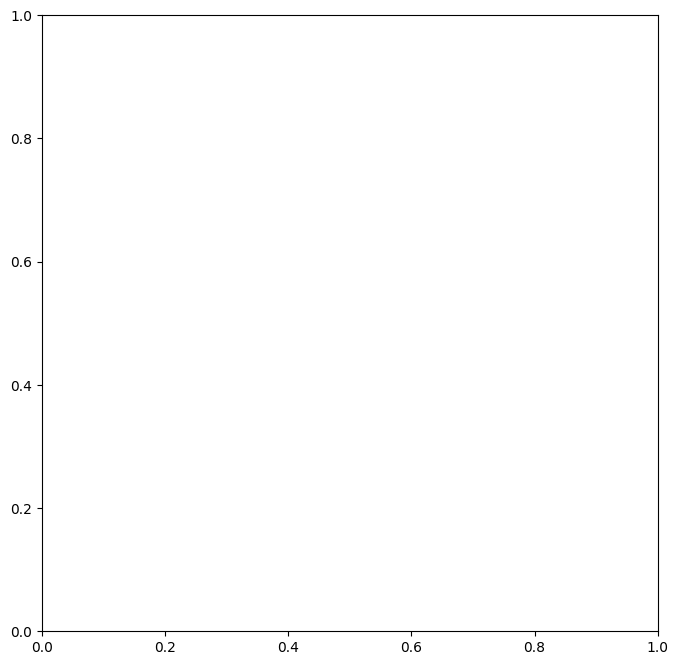

In [11]:
main()